# Database Management (SI424) Final Project: UPSA Alumni Analysis

- Data source: [UPSA Alumni](https://www.upsa.edu.bo/es/graduados-upsa/)
- Data format: HTML table, distributed by years and grouped/tabbed by faculty.


## Data Scraping and Cleaning

Firstly, we'll scrape the data from the UPSA Alumni page table.

In [20]:
from bs4 import BeautifulSoup
from httpx import get
import pandas as pd
import duckdb
import json
import polars as pl

In [21]:
UPSA_ALUMNI_URL = "https://www.upsa.edu.bo/es/graduados-upsa/"
response = get(UPSA_ALUMNI_URL)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

alumni_raw = [
    [cols[0], cols[1], faculty_name, cols[2], cols[3]]
    for year_div in soup.find_all("div", id=lambda x: x and x.isdigit())
    for link in year_div.find_all("a", attrs={"data-toggle": "tab"})
    for tab_id, faculty_name in [(link["href"].replace("#", ""), link.text.strip())]
    for tab_content in [year_div.find("div", id=tab_id)]
    if tab_content
    for table in [tab_content.find("table")]
    if table
    for row in table.find_all("tr")[1:]
    if len(row.find_all("td")) == 4
    for cols in [[td.text.strip() for td in row.find_all("td")]]
]


Then, we'll save it into a DuckDB table for further analysis, given that the data has typos, we'll clean it up and also map the careers to their respective faculties.

In [22]:
duckdb.sql("""
    DROP TABLE IF EXISTS alumni_raw;
    CREATE TABLE IF NOT EXISTS alumni_raw(
        name VARCHAR,
        career VARCHAR,
        faculty VARCHAR,
        graduation_date DATE,
        graduation_year INTEGER
    );
""")

duckdb.executemany("INSERT INTO alumni_raw VALUES (?, ?, ?, ?, ?);", alumni_raw)

alumni_raw_df = duckdb.sql("SELECT * FROM alumni_raw;").df()
alumni_raw_df

,name,career,faculty,graduation_date,graduation_year
0,Aguilera Sánchez Cecilia,Arquitectura,"ARQUITECTURA, DISENO Y URBANISMO",2022-05-04,2022
1,Barrera Saavedra Daniel Javier,Arquitectura,"ARQUITECTURA, DISENO Y URBANISMO",2022-10-06,2022
2,Bravo Lafuente Sara Desiree,Arquitectura,"ARQUITECTURA, DISENO Y URBANISMO",2022-10-11,2022
3,Carrion Guerra Paola Rosario,Arquitectura,"ARQUITECTURA, DISENO Y URBANISMO",2022-09-13,2022
4,Casso Paredes María Fernanda,Arquitectura,"ARQUITECTURA, DISENO Y URBANISMO",2022-05-27,2022
...,...,...,...,...,...
10252,EID MELGAR NADIA JANDIRA,ADMINISTRACION DE EMPRESAS,CIENCIAS EMPRESARIALES,1988-12-15,1988
10253,ANTELO SCOTT ROBERTO,COMUNICACION ESTRATEGICA Y CORPORATIVA,HUMANIDADES Y COMUNICACION,1988-12-15,1988
10254,ARIAS MEDINA SUSANA ESTHER,COMUNICACION ESTRATEGICA Y CORPORATIVA,HUMANIDADES Y COMUNICACION,1988-12-15,1988
10255,ROCA URIOSTE VANYA MÓNICA,COMUNICACION ESTRATEGICA Y CORPORATIVA,HUMANIDADES Y COMUNICACION,1988-12-14,1988


### Data Cleaning


First, we Title Case the names, careers, and faculties to ensure consistency.

In [23]:
alumni_cleaned_df = alumni_raw_df.copy()
alumni_cleaned_df["career"] = alumni_cleaned_df["career"].str.title()
alumni_cleaned_df["faculty"] = alumni_cleaned_df["faculty"].str.title()
alumni_cleaned_df["name"] = alumni_cleaned_df["name"].str.title()
alumni_cleaned_df

,name,career,faculty,graduation_date,graduation_year
0,Aguilera Sánchez Cecilia,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-04,2022
1,Barrera Saavedra Daniel Javier,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-06,2022
2,Bravo Lafuente Sara Desiree,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-11,2022
3,Carrion Guerra Paola Rosario,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-09-13,2022
4,Casso Paredes María Fernanda,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-27,2022
...,...,...,...,...,...
10252,Eid Melgar Nadia Jandira,Administracion De Empresas,Ciencias Empresariales,1988-12-15,1988
10253,Antelo Scott Roberto,Comunicacion Estrategica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988
10254,Arias Medina Susana Esther,Comunicacion Estrategica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988
10255,Roca Urioste Vanya Mónica,Comunicacion Estrategica Y Corporativa,Humanidades Y Comunicacion,1988-12-14,1988


We see that there are around 90 different careers, some with typos.
So these need to be standardized.

In [24]:
duckdb.sql("SELECT DISTINCT career FROM alumni_cleaned_df;").df()

,career
0,Auditoria Y Finanzas
1,Ingenieria Económica
2,Ingenieria De Redes Y Telecomunicaciones
3,Ingeniería En Redes Y Telecomunicaciones
4,Ingeniería Econ—Mica
...,...
59,Ingeniería Civil
60,Ingenieria Electrónica
61,Comunicacion Estrategica Y Corporativa
62,Psicologêa


Faculties are fine.

In [25]:
duckdb.sql("SELECT DISTINCT faculty FROM alumni_cleaned_df;").df()

,faculty
0,Humanidades Y Comunicacion
1,"Arquitectura, Diseno Y Urbanismo"
2,Ciencias Juridicas Y Sociales
3,Ingenieria
4,Ciencias Empresariales


We replace the careers with a mapping from a JSON file `mappings/careers.json`, 

In [26]:
with open("mapping/careers.json", "r") as f:
    career_map = json.load(f)

alumni_cleaned_df["career"] = alumni_cleaned_df["career"].replace(career_map)
duckdb.sql("SELECT DISTINCT career FROM alumni_cleaned_df;").df()

,career
0,Ingeniería Comercial
1,Ingeniería Financiera
2,Periodismo
3,Ingeniería De Redes Y Telecomunicaciones
4,Diseño Industrial
5,Auditoría Y Finanzas
6,Comercio Internacional
7,Ingeniería De Sistemas
8,Decoración De Interiores Y Paisajismo
9,Arquitectura


In [27]:
duckdb.sql("""
   CREATE TABLE IF NOT EXISTS alumni_cleaned AS
      SELECT * FROM alumni_cleaned_df;
   DROP TABLE IF EXISTS alumni_raw;
""")

In [28]:
alumni_df = alumni_cleaned_df.copy()
alumni_df


,name,career,faculty,graduation_date,graduation_year
0,Aguilera Sánchez Cecilia,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-04,2022
1,Barrera Saavedra Daniel Javier,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-06,2022
2,Bravo Lafuente Sara Desiree,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-11,2022
3,Carrion Guerra Paola Rosario,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-09-13,2022
4,Casso Paredes María Fernanda,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-27,2022
...,...,...,...,...,...
10252,Eid Melgar Nadia Jandira,Administración De Empresas,Ciencias Empresariales,1988-12-15,1988
10253,Antelo Scott Roberto,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988
10254,Arias Medina Susana Esther,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988
10255,Roca Urioste Vanya Mónica,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-14,1988


In [29]:
names_with_commas = duckdb.sql("""
    SELECT DISTINCT name FROM alumni_cleaned_df
    WHERE name LIKE '%,%';
""").df()
names_with_commas

,name
0,"Castedo Ruiz, Gabriela"
1,"Tavera Achá, Isabel"
2,"Mejía Palacios, Franco Alejandro"
3,"Núñez Pinaya, Ana Laura"
4,"Rojas Peñafiel, Carlos Eduardo"
...,...
451,"Saba Salomón, María Claudia"
452,"López Paniagua, Jesús Andrés"
453,"Rivero Zambrana, Valeria Alejandra"
454,"Escobar Basilio, Percy David"


In [30]:
def parse_comma_name(name):
    if ',' not in name:
        return None

    # Split by comma
    parts = name.split(',')
    if len(parts) != 2:
        return None

    last_names_part = parts[0].strip()
    first_names_part = parts[1].strip()

    # Split last names - typically 2 words, but handle compound surnames
    last_names = last_names_part.split()

    # Handle compound surnames with "De", "Del", "De La", "De Las", etc.
    paternal_last_name = []
    maternal_last_name = []

    i = 0
    # First, collect paternal surname (can be compound)
    while i < len(last_names):
        word = last_names[i]
        paternal_last_name.append(word)
        i += 1

        # Check if current word is a preposition that continues the compound surname
        if word.lower() in ['de', 'del', 'da', 'dos', 'das', 'y']:
            # Continue collecting words for compound surname
            continue
        # Check if next word is a preposition that continues the compound surname
        elif i < len(last_names) and last_names[i].lower() in ['la', 'las', 'los', 'le']:
            # These prepositions usually follow 'de', continue collecting
            continue
        else:
            # If we have at least 2 words collected and there are remaining words,
            # the remaining should be maternal surname
            if len(paternal_last_name) >= 1 and i < len(last_names):
                break

    # Remaining words are maternal surname
    maternal_last_name = last_names[i:]

    # If we only have one surname total, try to split it
    if not maternal_last_name and len(paternal_last_name) > 1:
        # If paternal has multiple words but no maternal, take last word as maternal
        # unless it's part of a compound (like "De Las")
        if paternal_last_name[-1].lower() not in ['la', 'las', 'los', 'le']:
            maternal_last_name = [paternal_last_name.pop()]

    # Parse first names
    first_names = first_names_part.split()
    first_name = first_names[0] if first_names else ""
    middle_names = " ".join(first_names[1:]) if len(first_names) > 1 else ""

    # Create clean full name without comma
    clean_full_name = f"{' '.join(paternal_last_name)} {' '.join(maternal_last_name)} {first_names_part}".strip()

    return {
        'clean_full_name': clean_full_name,
        'paternal_last_name': ' '.join(paternal_last_name),
        'maternal_last_name': ' '.join(maternal_last_name),
        'first_name': first_name,
        'middle_names': middle_names
    }


In [31]:
# Add new columns to the dataframe
alumni_df['paternal_last_name'] = ""
alumni_df['maternal_last_name'] = ""
alumni_df['first_name'] = ""
alumni_df['middle_names'] = ""

# Process names with commas
comma_mask = alumni_df['name'].str.contains(',', na=False)
comma_names = alumni_df[comma_mask]['name'].tolist()

print(f"Processing {len(comma_names)} names with commas...")

for idx, row in alumni_df[comma_mask].iterrows():
    result = parse_comma_name(row['name'])
    if result:
        # Update the name to clean version (without comma)
        alumni_df.at[idx, 'name'] = result['clean_full_name']
        alumni_df.at[idx, 'paternal_last_name'] = result['paternal_last_name']
        alumni_df.at[idx, 'maternal_last_name'] = result['maternal_last_name']
        alumni_df.at[idx, 'first_name'] = result['first_name']
        alumni_df.at[idx, 'middle_names'] = result['middle_names']

# Show sample of processed data
processed_sample = alumni_df[alumni_df['paternal_last_name'] != ''].head(10)
print("\nSample of processed names:")
for _, row in processed_sample.iterrows():
    print(f"Full: {row['name']}")
    print(f"  Paternal: {row['paternal_last_name']}")
    print(f"  Maternal: {row['maternal_last_name']}")
    print(f"  First: {row['first_name']}")
    print(f"  Middle: {row['middle_names']}")
    print()

print(f"\nDataset shape: {alumni_df.shape}")
print(f"Names processed with commas: {len(alumni_df[alumni_df['paternal_last_name'] != ''])}")
print(f"Names still to process: {len(alumni_df[alumni_df['paternal_last_name'] == ''])}")

Processing 456 names with commas...

Sample of processed names:
Full: Abdeljalin Bernabet Andrea
  Paternal: Abdeljalin
  Maternal: Bernabet
  First: Andrea
  Middle: 

Full: Abdeljalin Bernabet Cristhian Hassan
  Paternal: Abdeljalin
  Maternal: Bernabet
  First: Cristhian
  Middle: Hassan

Full: Aguilera Tarradelles Diego Armando
  Paternal: Aguilera
  Maternal: Tarradelles
  First: Diego
  Middle: Armando

Full: Aguirre Suárez Ximena
  Paternal: Aguirre
  Maternal: Suárez
  First: Ximena
  Middle: 

Full: Aguirre Vargas Marcela
  Paternal: Aguirre
  Maternal: Vargas
  First: Marcela
  Middle: 

Full: Arandia Mansilla Maydelení
  Paternal: Arandia
  Maternal: Mansilla
  First: Maydelení
  Middle: 

Full: Arandia Padilla Rhandy Limberg
  Paternal: Arandia
  Maternal: Padilla
  First: Rhandy
  Middle: Limberg

Full: Balcázar Carrasco Rodrigo
  Paternal: Balcázar
  Maternal: Carrasco
  First: Rodrigo
  Middle: 

Full: Balderrama Soliz Donald Fabio
  Paternal: Balderrama
  Maternal: Soli

In [32]:
alumni_df

,name,career,faculty,graduation_date,graduation_year,paternal_last_name,maternal_last_name,first_name,middle_names
0,Aguilera Sánchez Cecilia,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-04,2022,,,,
1,Barrera Saavedra Daniel Javier,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-06,2022,,,,
2,Bravo Lafuente Sara Desiree,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-10-11,2022,,,,
3,Carrion Guerra Paola Rosario,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-09-13,2022,,,,
4,Casso Paredes María Fernanda,Arquitectura,"Arquitectura, Diseno Y Urbanismo",2022-05-27,2022,,,,
...,...,...,...,...,...,...,...,...,...
10252,Eid Melgar Nadia Jandira,Administración De Empresas,Ciencias Empresariales,1988-12-15,1988,,,,
10253,Antelo Scott Roberto,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988,,,,
10254,Arias Medina Susana Esther,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-15,1988,,,,
10255,Roca Urioste Vanya Mónica,Comunicación Estratégica Y Corporativa,Humanidades Y Comunicacion,1988-12-14,1988,,,,


We can now add more information to the dataset.
Such as:

- Graduation decade, month, weekday, date (without year),
- Name data:
  - First name, middle name, last name (paternal and maternal),
  - Full name (with and without middle name, removing the comma some might have),

In [33]:
def parse_non_comma_name(name):
    """
    Parse Spanish names without comma format: "Paternal Maternal First Middle"
    Returns a dictionary with parsed components
    """
    if not name or name.strip() == "":
        return None

    words = name.strip().split()
    n = len(words)

    if n < 2:
        return {
            'clean_full_name': name,
            'paternal_last_name': words[0] if words else "",
            'maternal_last_name': "",
            'first_name': "",
            'middle_names': ""
        }

    # Handle 2 and 3 word names as before
    if n == 2:
        return {
            'clean_full_name': name,
            'paternal_last_name': words[0],
            'maternal_last_name': "",
            'first_name': words[1],
            'middle_names': ""
        }
    if n == 3:
        return {
            'clean_full_name': name,
            'paternal_last_name': words[0],
            'maternal_last_name': words[1],
            'first_name': words[2],
            'middle_names': ""
        }

    # For 4+ words, check for compound surnames
    surname_particles = ['de', 'del', 'la', 'las', 'los', 'y', 'da', 'das', 'dos']
    # Check if the first three words form a compound surname (e.g., "De La Cruz")
    if n >= 5 and words[0].lower() in surname_particles and words[1].lower() in surname_particles:
        # e.g., "De La Cruz Mendoza Carlos Eduardo"
        paternal_last_name = " ".join(words[:3])
        maternal_last_name = words[3]
        first_name = words[4]
        middle_names = " ".join(words[5:]) if n > 5 else ""
    elif n >= 4 and words[0].lower() in surname_particles:
        # e.g., "Del Valle Perez Ana Maria"
        paternal_last_name = " ".join(words[:2])
        maternal_last_name = words[2]
        first_name = words[3]
        middle_names = " ".join(words[4:]) if n > 4 else ""
    else:
        # Default: first two are last names, rest are first/middle names
        paternal_last_name = words[0]
        maternal_last_name = words[1]
        first_name = words[2]
        middle_names = " ".join(words[3:]) if n > 3 else ""

    return {
        'clean_full_name': name,
        'paternal_last_name': paternal_last_name,
        'maternal_last_name': maternal_last_name,
        'first_name': first_name,
        'middle_names': middle_names
    }


In [101]:
unprocessed_mask = (alumni_df["paternal_last_name"] == "") & (alumni_df["name"].notna())
unprocessed_names = alumni_df[unprocessed_mask]["name"].tolist()

for idx, row in alumni_df[unprocessed_mask].iterrows():
    result = parse_non_comma_name(row["name"])
    if result:
        alumni_df.at[idx, "paternal_last_name"] = result["paternal_last_name"]
        alumni_df.at[idx, "maternal_last_name"] = result["maternal_last_name"]
        alumni_df.at[idx, "first_name"] = result["first_name"]
        alumni_df.at[idx, "middle_names"] = result["middle_names"]

newly_processed_sample = alumni_df[
    (alumni_df["paternal_last_name"] != "")
    & (~alumni_df["name"].str.contains(",", na=False))
].head(10)


In [102]:
alumni_df["graduation_decade"] = (alumni_df["graduation_year"] // 10) * 10
alumni_df["graduation_month"] = pd.to_datetime(alumni_df["graduation_date"]).dt.month
alumni_df["graduation_weekday"] = pd.to_datetime(
    alumni_df["graduation_date"]
).dt.weekday
alumni_df["graduation_date_only"] = pd.to_datetime(
    alumni_df["graduation_date"]
).dt.strftime("%d-%m")
alumni_df["graduation_semester"] = alumni_df["graduation_month"].apply(
    lambda x: "First"
    if x in [1, 2, 3, 4, 5, 6]
    else "Second"
    if x in [7, 8, 9, 10, 11, 12]
    else None
)
# southern hemisphere seasons
alumni_df["graduation_season"] = alumni_df["graduation_month"].apply(
    lambda x: "Summer"
    if x in [12, 1, 2]
    else "Autumn"
    if x in [3, 4, 5]
    else "Winter"
    if x in [6, 7, 8]
    else "Spring"
    if x in [9, 10, 11]
    else None
)
# get the full name initials
alumni_df["name_initials"] = alumni_df.apply(
    lambda row: " ".join([name[0] for name in row["name"].split() if name]), axis=1
)
alumni_df["graduation_quarter"] = pd.to_datetime(
    alumni_df["graduation_date"]
).dt.quarter
alumni_df["has_middle_name"] = alumni_df["middle_names"].apply(
    lambda x: bool(x.strip())
)
alumni_df["has_maternal_last_name"] = alumni_df["maternal_last_name"].apply(
    lambda x: bool(x.strip())
)
alumni_df["graduation_day_of_the_year"] = pd.to_datetime(
    alumni_df["graduation_date"]
).dt.dayofyear
alumni_df["graduation_week_of_year"] = (
    pd.to_datetime(alumni_df["graduation_date"]).dt.isocalendar().week
)
alumni_df["graduation_day_of_month"] = pd.to_datetime(
    alumni_df["graduation_date"]
).dt.day
alumni_df["graduation_on_weekend"] = alumni_df["graduation_weekday"].apply(
    lambda x: x in [4, 5, 6]
)
alumni_df["name_word_count"] = alumni_df["name"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)
alumni_df["name_char_count"] = alumni_df["name"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

## Data Exploration and Analysis

Firstly we'll start with some exploration of the dataset.

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px

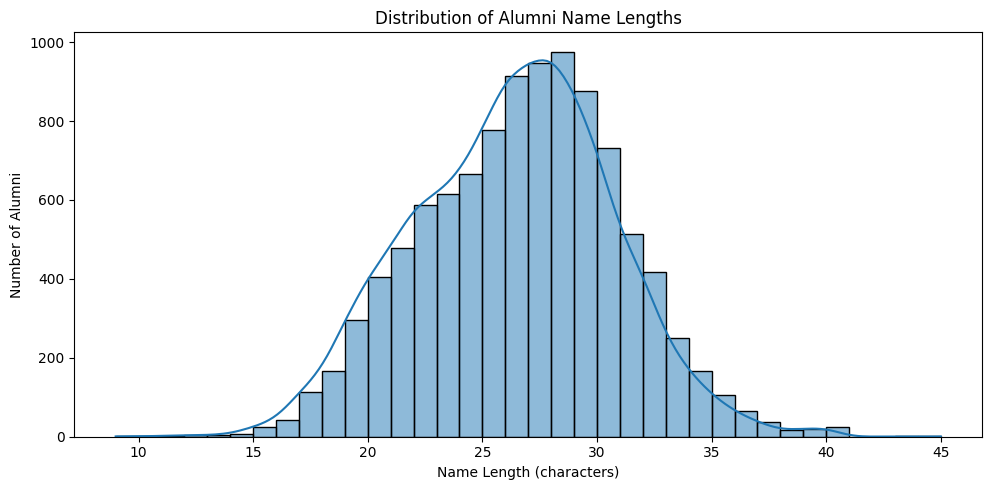

In [93]:
plt.figure(figsize=(10, 5))
plt.title("Distribution of Alumni Name Lengths")
plt.xlabel("Name Length (characters)")
plt.ylabel("Number of Alumni")
plt.tight_layout()
sns.histplot(alumni_df, x="name_char_count", kde=True, binwidth=1, )
plt.show()

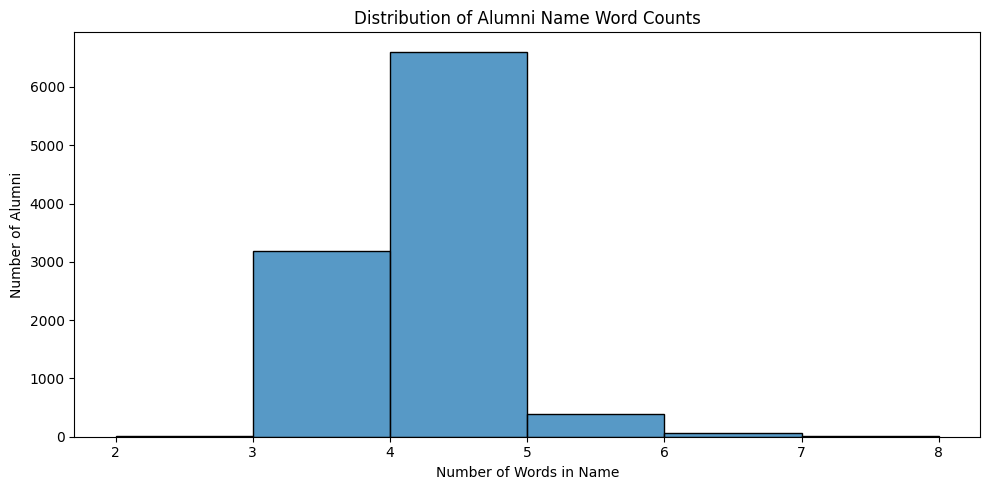

In [97]:
plt.figure(figsize=(10, 5))
sns.histplot(alumni_df["name_word_count"], binwidth=1)
plt.title("Distribution of Alumni Name Word Counts")
plt.xlabel("Number of Words in Name")
plt.ylabel("Number of Alumni")
plt.tight_layout()
plt.show()


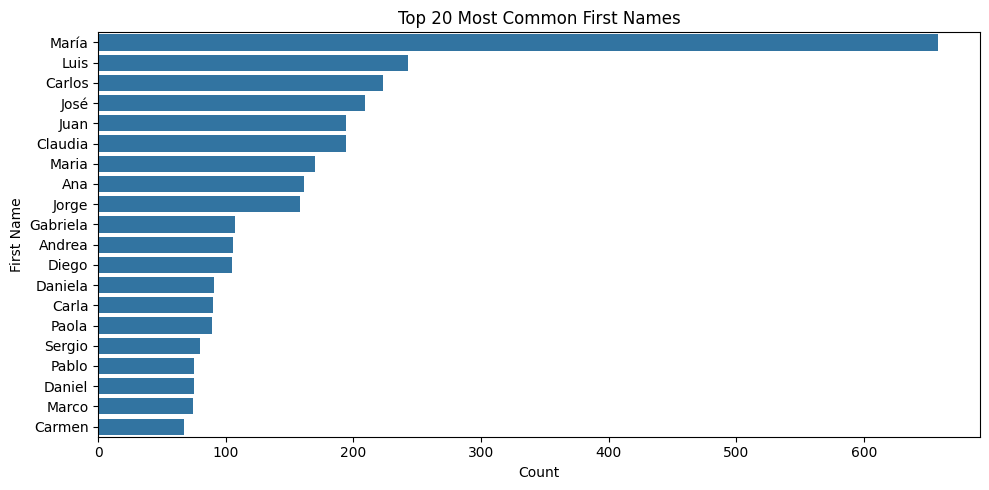

In [ ]:
first_name_counts = alumni_df["first_name"].value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=first_name_counts.index, x=first_name_counts.values)
plt.title("Top 20 Most Common First Names")
plt.xlabel("Count")
plt.ylabel("First Name")
plt.tight_layout()
plt.show()


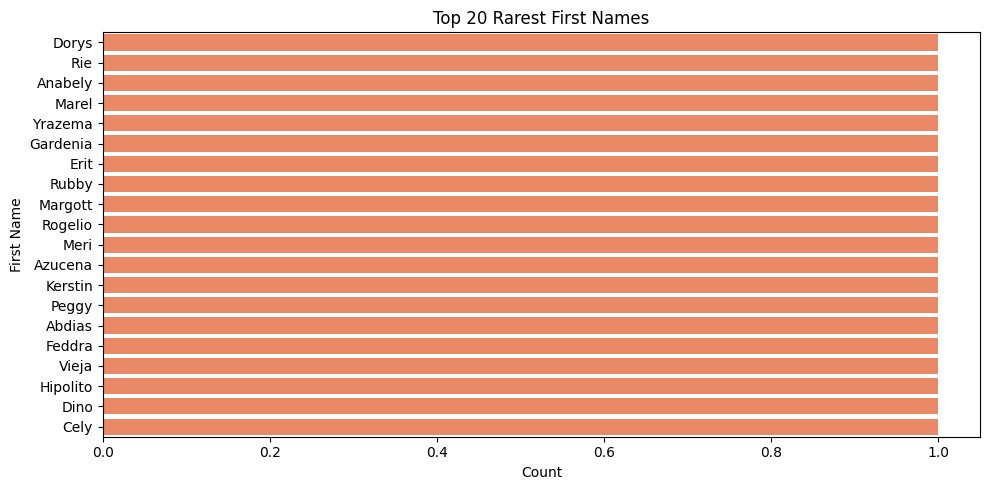

In [106]:
rare_first_names = alumni_df["first_name"].value_counts().tail(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=rare_first_names.index, x=rare_first_names.values, color="coral")
plt.title("Top 20 Rarest First Names")
plt.xlabel("Count")
plt.ylabel("First Name")
plt.tight_layout()
plt.show()

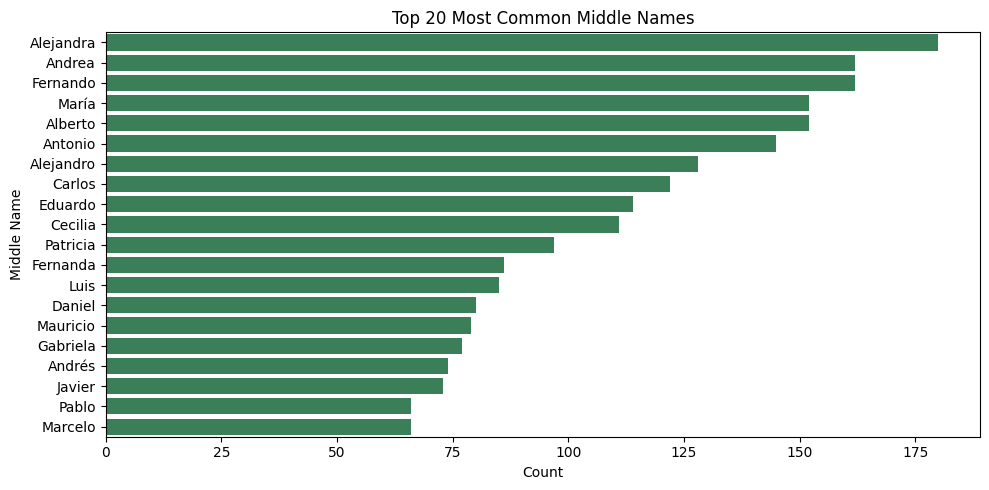

In [107]:
middle_name_counts = alumni_df[alumni_df["middle_names"].str.strip() != ""]["middle_names"].str.split().explode().value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=middle_name_counts.index, x=middle_name_counts.values, color="seagreen")
plt.title("Top 20 Most Common Middle Names")
plt.xlabel("Count")
plt.ylabel("Middle Name")
plt.tight_layout()
plt.show()


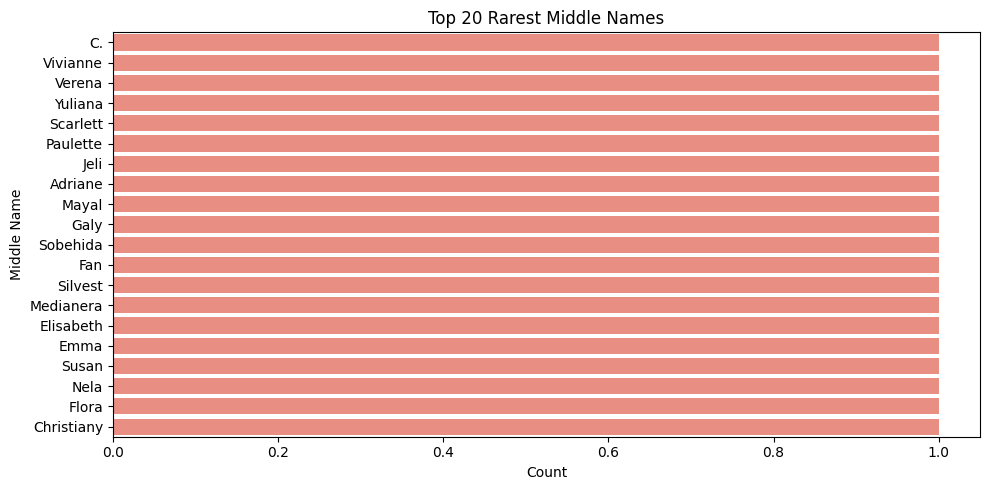

In [108]:
rare_middle_names = alumni_df[alumni_df["middle_names"].str.strip() != ""]["middle_names"].str.split().explode().value_counts().tail(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=rare_middle_names.index, x=rare_middle_names.values, color="salmon")
plt.title("Top 20 Rarest Middle Names")
plt.xlabel("Count")
plt.ylabel("Middle Name")
plt.tight_layout()
plt.show()

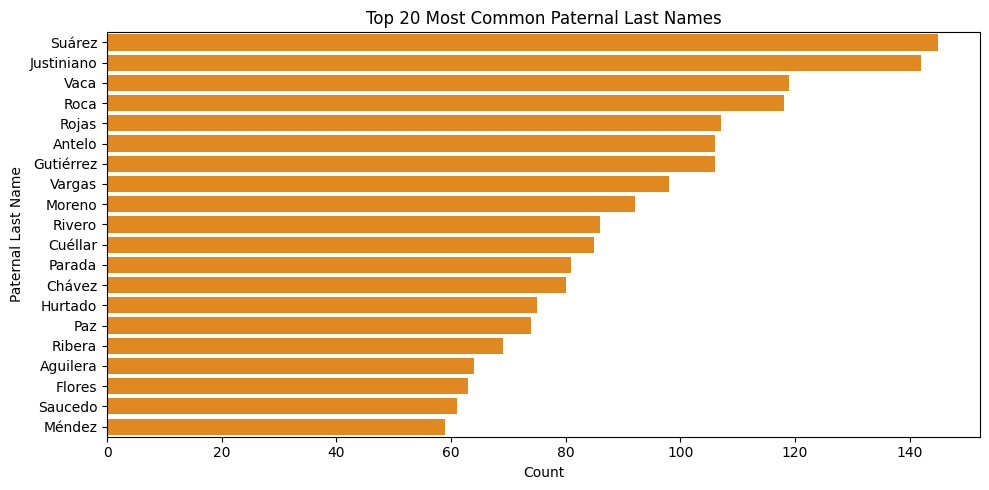

In [109]:
paternal_counts = alumni_df["paternal_last_name"].value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=paternal_counts.index, x=paternal_counts.values, color="darkorange")
plt.title("Top 20 Most Common Paternal Last Names")
plt.xlabel("Count")
plt.ylabel("Paternal Last Name")
plt.tight_layout()
plt.show()


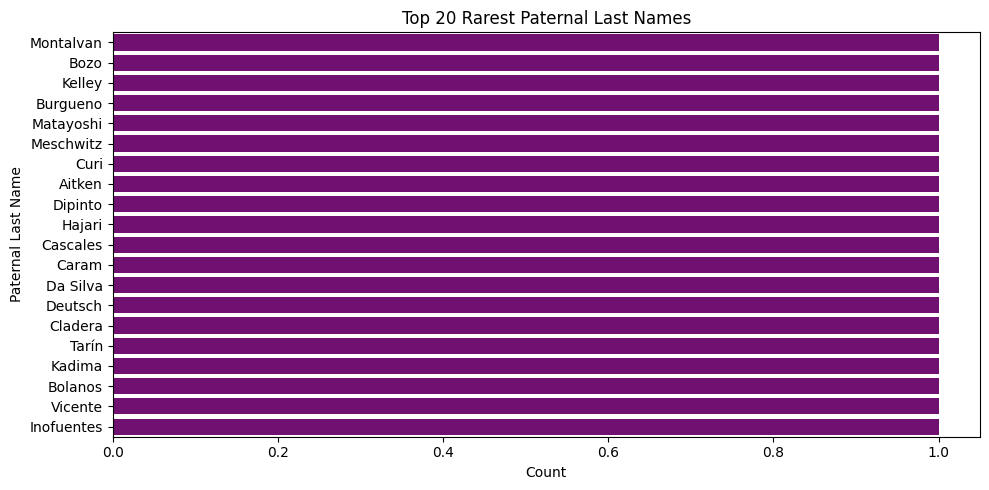

In [111]:
rare_paternal_names = alumni_df["paternal_last_name"].value_counts().tail(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=rare_paternal_names.index, x=rare_paternal_names.values, color="purple")
plt.title("Top 20 Rarest Paternal Last Names")
plt.xlabel("Count")
plt.ylabel("Paternal Last Name")
plt.tight_layout()
plt.show()


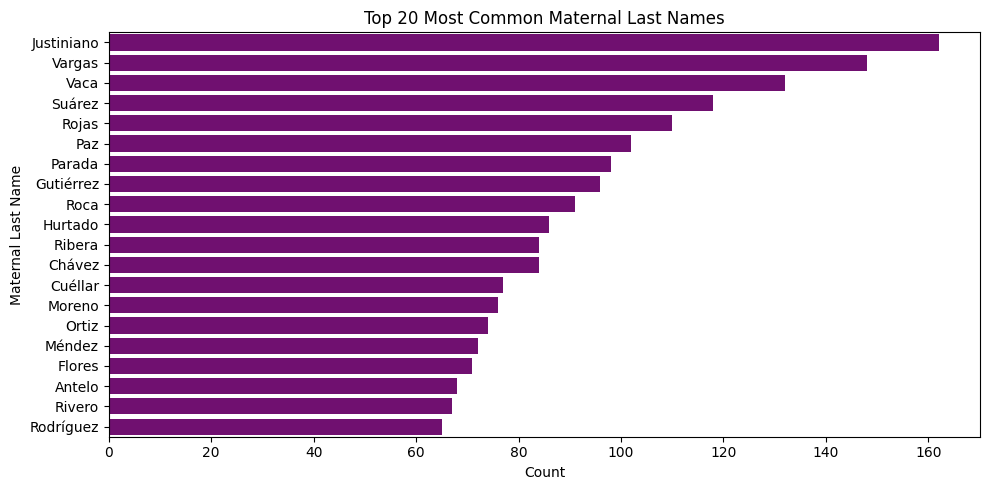

In [112]:
maternal_counts = alumni_df[alumni_df["maternal_last_name"].str.strip() != ""]["maternal_last_name"].value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=maternal_counts.index, x=maternal_counts.values, color="purple")
plt.title("Top 20 Most Common Maternal Last Names")
plt.xlabel("Count")
plt.ylabel("Maternal Last Name")
plt.tight_layout()
plt.show()


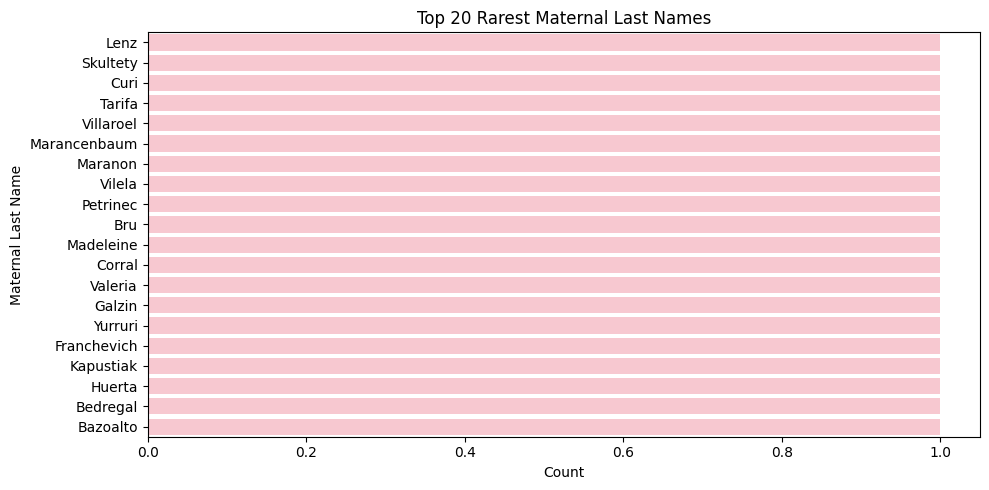

In [113]:
rare_maternal_names = alumni_df[alumni_df["maternal_last_name"].str.strip() != ""]["maternal_last_name"].value_counts().tail(20)
plt.figure(figsize=(10, 5))
sns.barplot(y=rare_maternal_names.index, x= rare_maternal_names.values, color="pink")
plt.title("Top 20 Rarest Maternal Last Names")
plt.xlabel("Count")
plt.ylabel("Maternal Last Name")
plt.tight_layout()
plt.show()

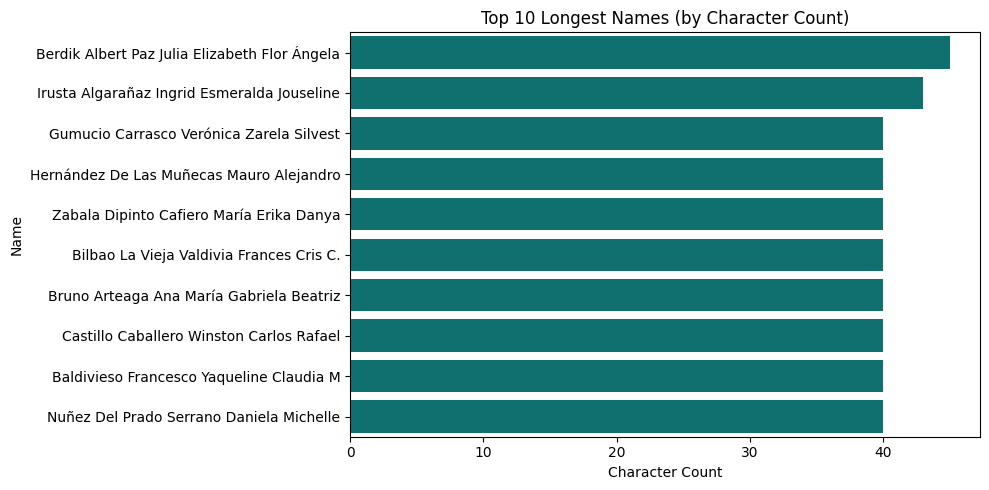

In [251]:

# Longest names by character count
longest_names = alumni_df.sort_values("name_char_count", ascending=False)[["name", "name_char_count"]].head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=longest_names["name"], x=longest_names["name_char_count"], color="teal")
plt.title("Top 10 Longest Names (by Character Count)")
plt.xlabel("Character Count")
plt.ylabel("Name")
plt.tight_layout()
plt.show()


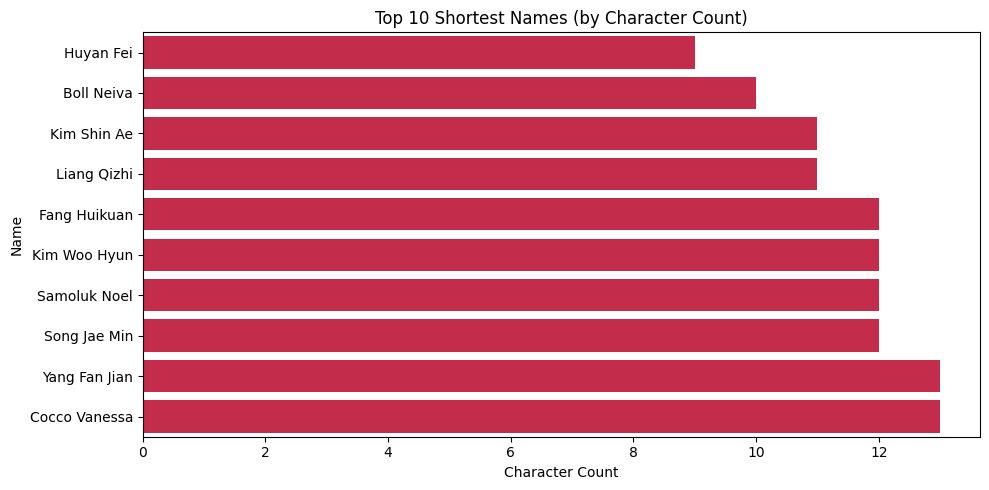

In [252]:

# Shortest names by character count
shortest_names = alumni_df.sort_values("name_char_count", ascending=True)[["name", "name_char_count"]].head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=shortest_names["name"], x=shortest_names["name_char_count"], color="crimson")
plt.title("Top 10 Shortest Names (by Character Count)")
plt.xlabel("Character Count")
plt.ylabel("Name")
plt.tight_layout()
plt.show()


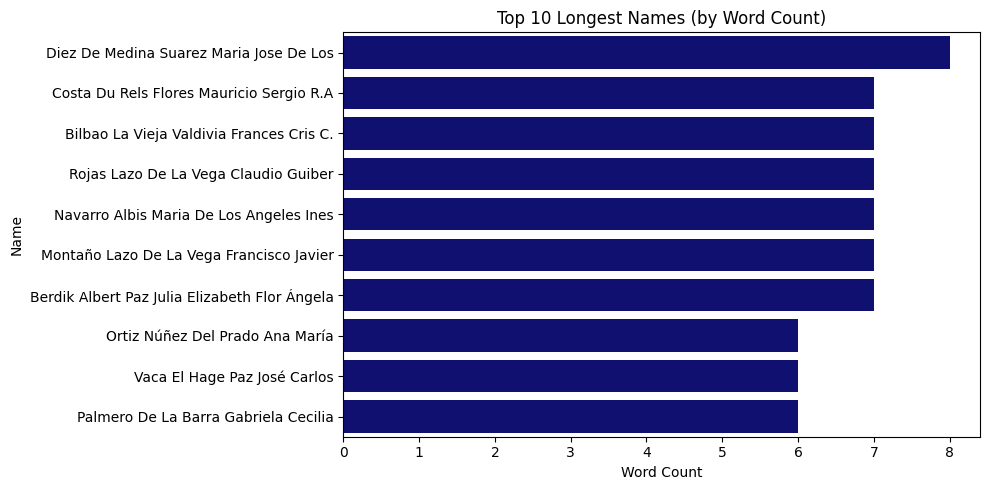

In [114]:
longest_word_names = alumni_df.sort_values("name_word_count", ascending=False)[["name", "name_word_count"]].head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=longest_word_names["name"], x=longest_word_names["name_word_count"], color="navy")
plt.title("Top 10 Longest Names (by Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Name")
plt.tight_layout()
plt.show()


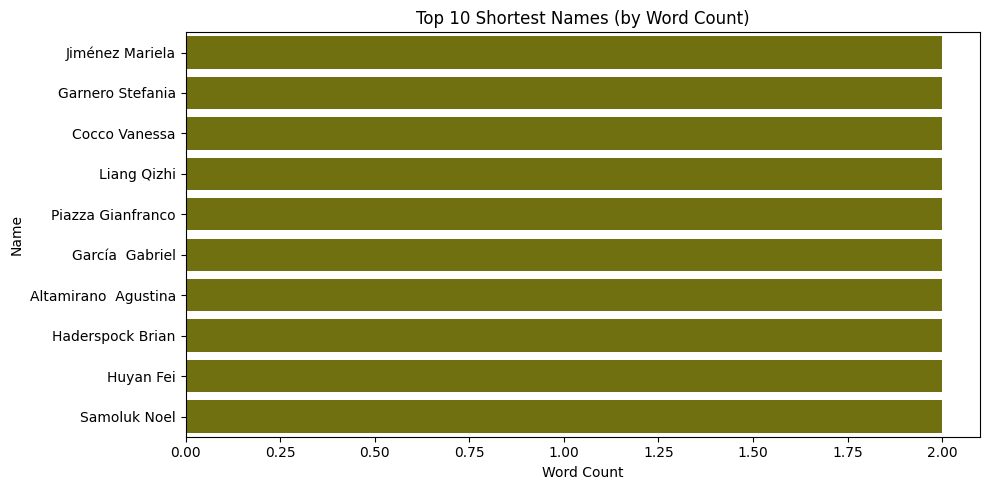

In [115]:
shortest_word_names = alumni_df.sort_values("name_word_count", ascending=True)[["name", "name_word_count"]].head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=shortest_word_names["name"], x=shortest_word_names["name_word_count"], color="olive")
plt.title("Top 10 Shortest Names (by Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Name")
plt.tight_layout()
plt.show()

In [116]:
# Count all careers and sort by count
career_counts = alumni_df["career"].value_counts().sort_values(ascending=True)

fig = px.bar(
    career_counts,
    x=career_counts.values,
    y=career_counts.index,
    orientation='h',
    labels={'x': 'Number of Alumni', 'y': 'Career'},
    title='Number of Alumni per Career (All Careers)',
    color=career_counts.values,
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.update_layout(
    showlegend=False,
    yaxis={'categoryorder':'total ascending'},
    height=25 * len(career_counts) if len(career_counts) < 40 else 1000,  # dynamic height
    margin=dict(l=200, r=20, t=60, b=40)
)
fig.update_traces(
    hovertemplate='<b>%{y}</b><br>Alumni: %{x}<extra></extra>'
)
fig.show()


In [37]:
faculty_counts = alumni_df["faculty"].value_counts().sort_values(ascending=True)

fig = px.bar(
    faculty_counts,
    x=faculty_counts.values,
    y=faculty_counts.index,
    orientation='h',
    labels={'x': 'Number of Alumni', 'y': 'Faculty'},
    title='Number of Alumni per Faculty',
    color=faculty_counts.values,
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.update_layout(
    showlegend=False,
    yaxis={'categoryorder':'total ascending'},
    height=60 * len(faculty_counts) if len(faculty_counts) < 20 else 1000,
    margin=dict(l=200, r=20, t=60, b=40)
)
fig.update_traces(
    hovertemplate='<b>%{y}</b><br>Alumni: %{x}<extra></extra>'
)
fig.show()


In [123]:
import plotly.express as px

career_faculty_counts = (
    alumni_df.groupby(['career', 'faculty'])
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    career_faculty_counts,
    x='count',
    y='career',
    color='faculty',
    orientation='h',
    labels={'count': 'Number of Alumni', 'career': 'Career', 'faculty': 'Faculty'},
    title='Number of Alumni per Career per Faculty',
    height=25 * career_faculty_counts["career"].nunique() if career_faculty_counts["career"].nunique() < 40 else 1000
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=200, r=20, t=60, b=40)
)
fig.update_traces(
    hovertemplate='<b>%{y}</b><br>Faculty: %{marker.color}<br>Alumni: %{x}<extra></extra>'
)
fig.show()

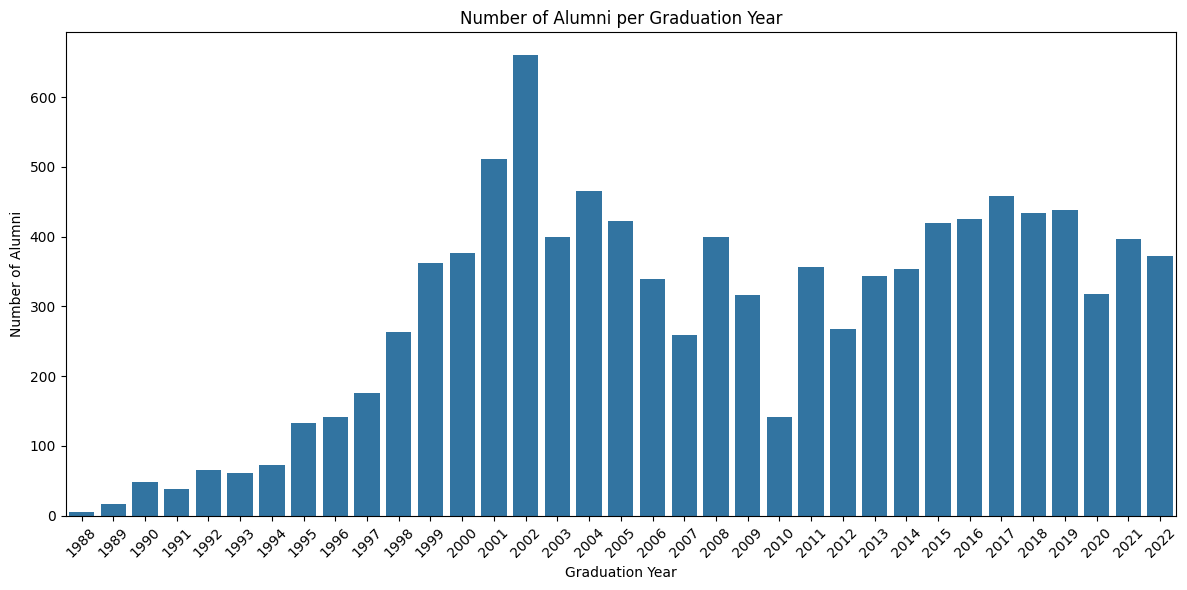

In [128]:
year_counts = alumni_df["graduation_year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title("Number of Alumni per Graduation Year")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


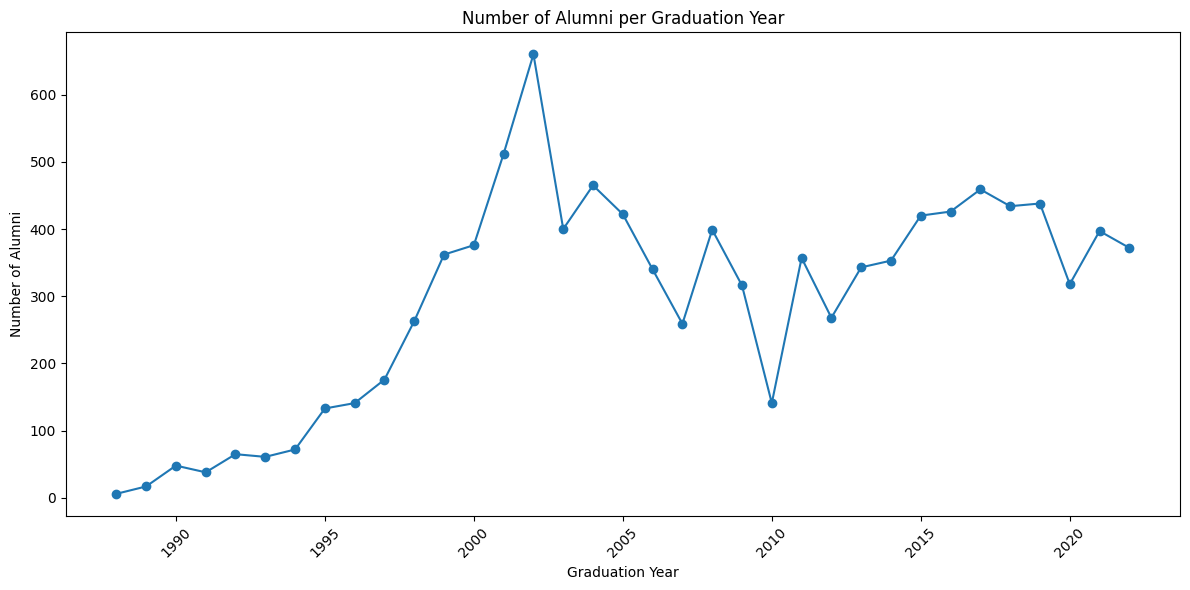

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Number of Alumni per Graduation Year")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


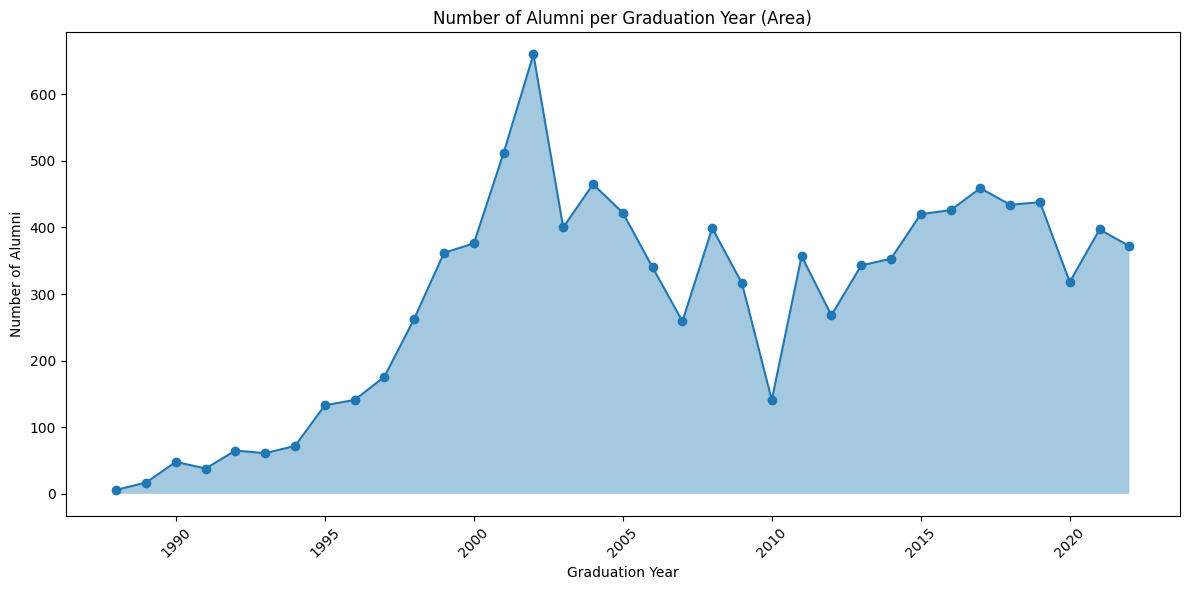

In [130]:
plt.figure(figsize=(12, 6))
plt.fill_between(year_counts.index, year_counts.values, alpha=0.4)
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Number of Alumni per Graduation Year (Area)")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

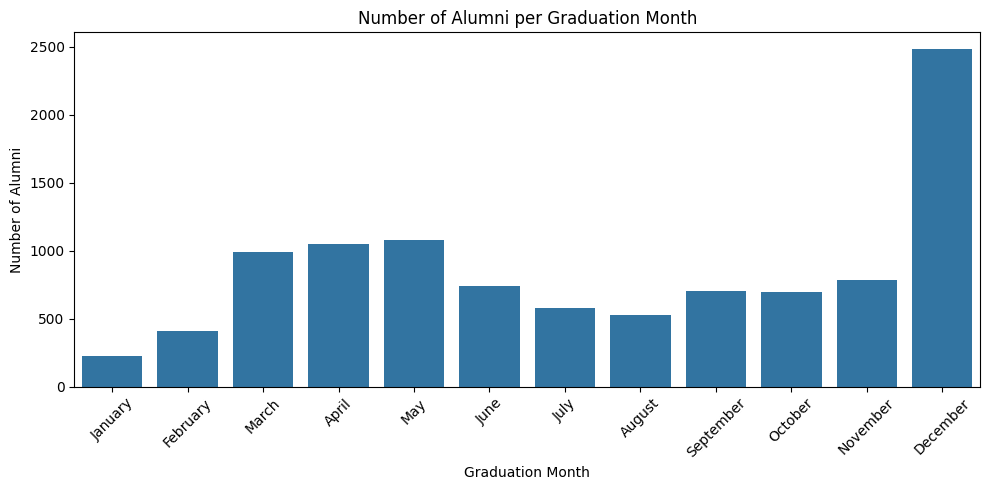

In [ ]:
month_counts = alumni_df["graduation_month"].value_counts().sort_index()
month_names = [pd.to_datetime(str(m), format='%m').strftime('%B') for m in month_counts.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=month_names, y=month_counts.values)
plt.title("Number of Alumni per Graduation Month")
plt.xlabel("Graduation Month")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


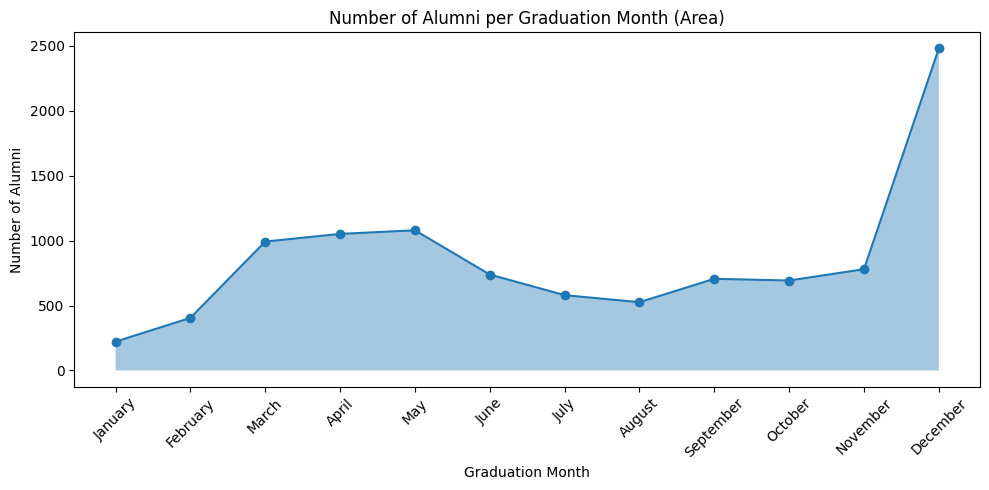

In [132]:
plt.figure(figsize=(10, 5))
plt.fill_between(month_names, month_counts.values, alpha=0.4)
plt.plot(month_names, month_counts.values, marker='o')
plt.title("Number of Alumni per Graduation Month (Area)")
plt.xlabel("Graduation Month")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


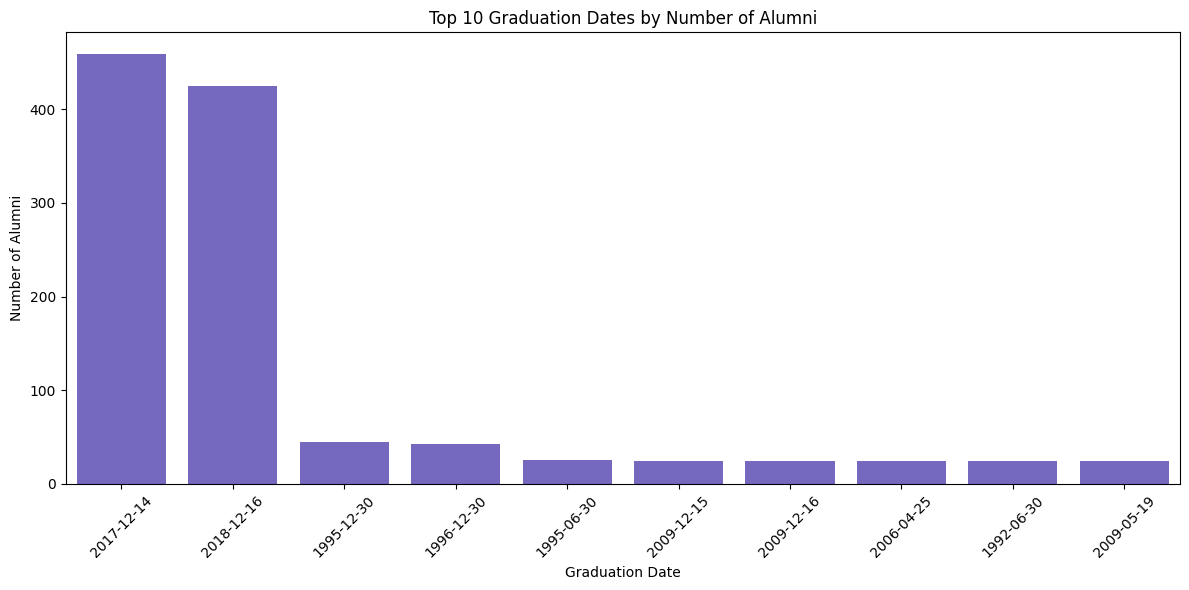

In [134]:
date_counts = alumni_df["graduation_date"].value_counts()
top_date = date_counts.idxmax()
top_count = date_counts.max()

plt.figure(figsize=(12, 6))
sns.barplot(x=date_counts.index[:10], y=date_counts.values[:10], color="slateblue")
plt.title("Top 10 Graduation Dates by Number of Alumni")
plt.xlabel("Graduation Date")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


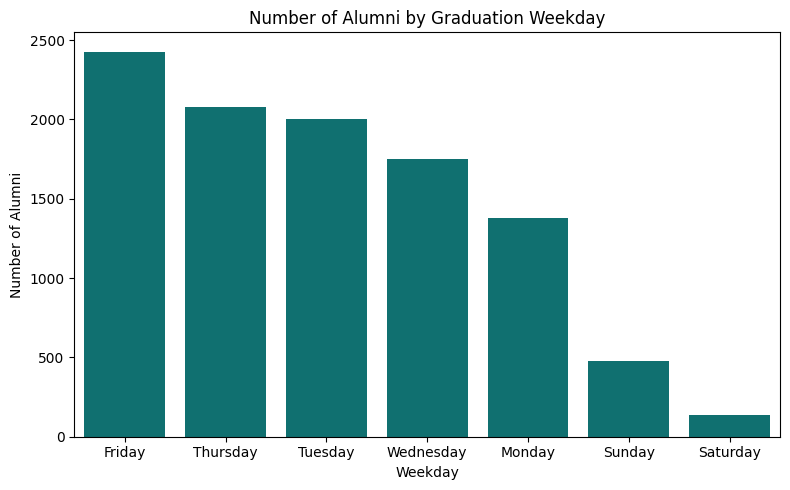

In [138]:
weekday_counts = alumni_df["graduation_weekday"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, color="teal")
plt.title("Number of Alumni by Graduation Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Alumni")
plt.tight_layout()
plt.show()


Career and faculty popularity over the years.

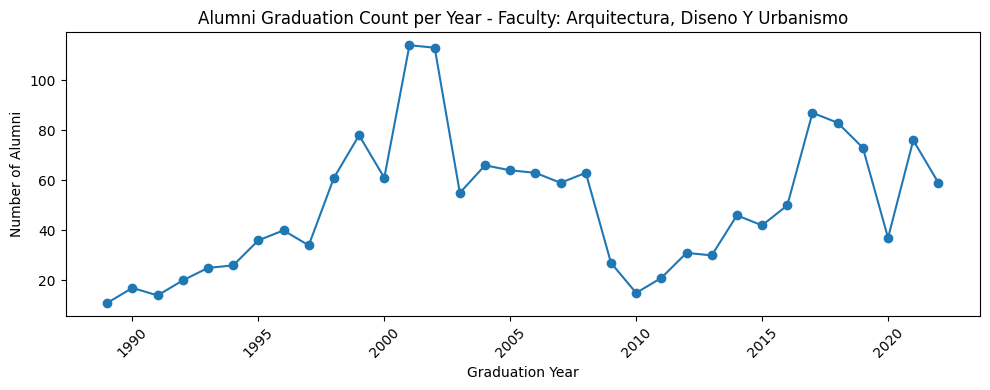

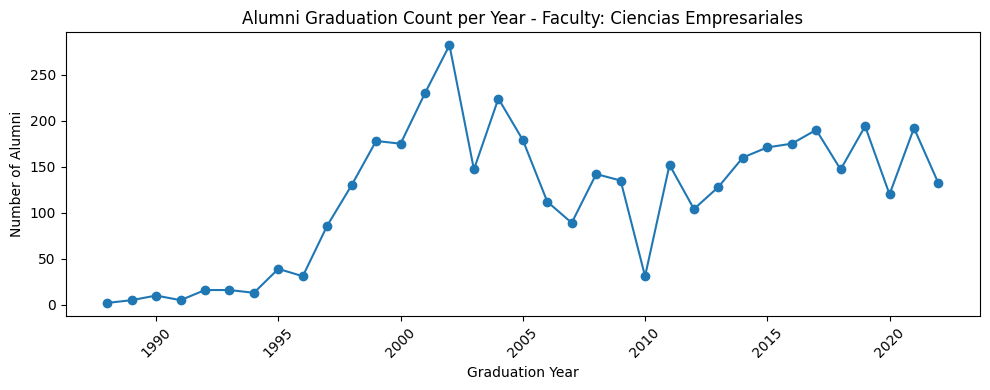

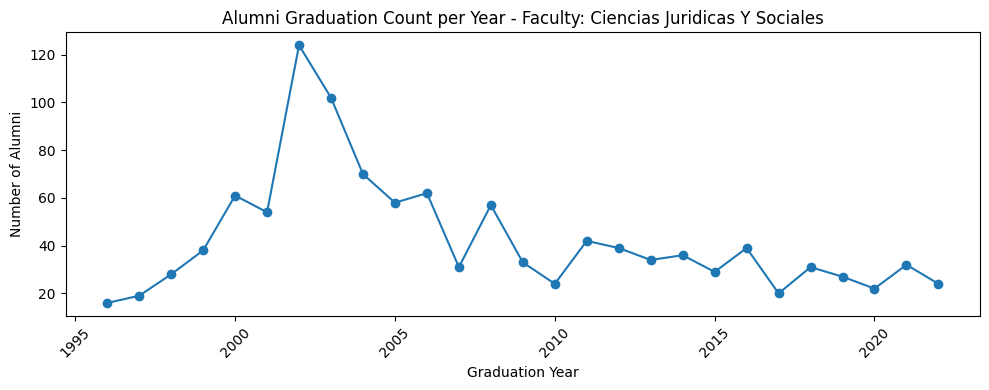

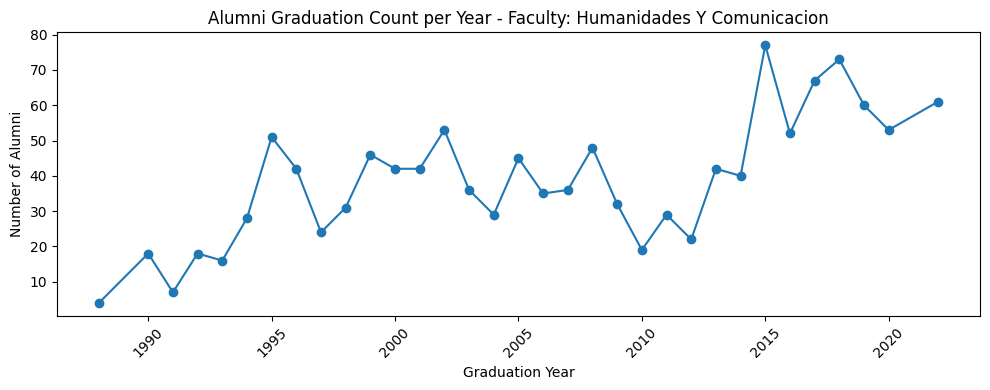

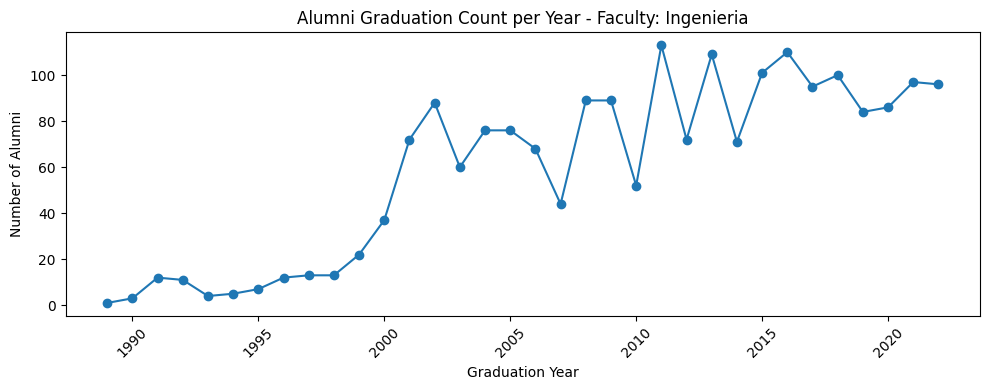

In [140]:
# Plot popularity of each faculty over the years
faculties = alumni_df["faculty"].unique()
for faculty in faculties:
    faculty_year_counts = (
        alumni_df[alumni_df["faculty"] == faculty]["graduation_year"]
        .value_counts()
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(faculty_year_counts.index, faculty_year_counts.values, marker='o')
    plt.title(f"Alumni Graduation Count per Year - Faculty: {faculty}")
    plt.xlabel("Graduation Year")
    plt.ylabel("Number of Alumni")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


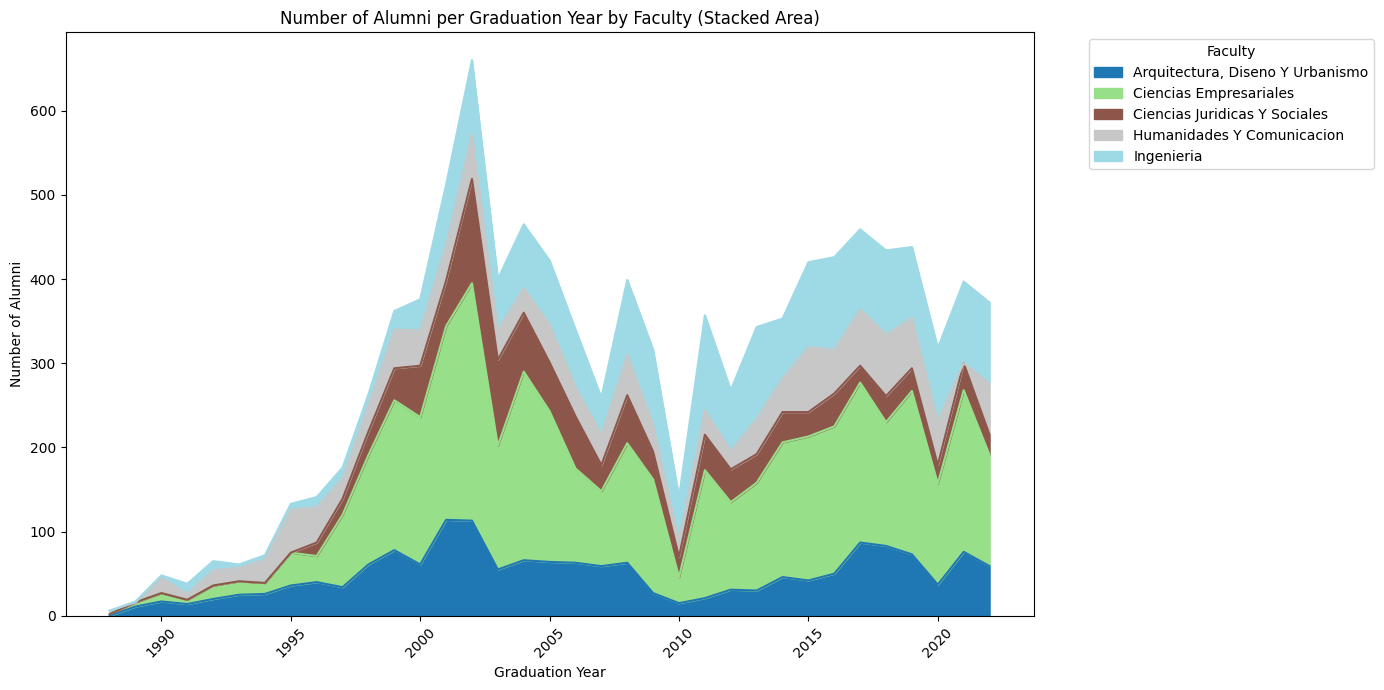

In [149]:
faculty_year_df = (
    alumni_df.groupby(['graduation_year', 'faculty'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

faculty_year_df.plot(
    kind='area',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title("Number of Alumni per Graduation Year by Faculty (Stacked Area)")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.legend(title="Faculty", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


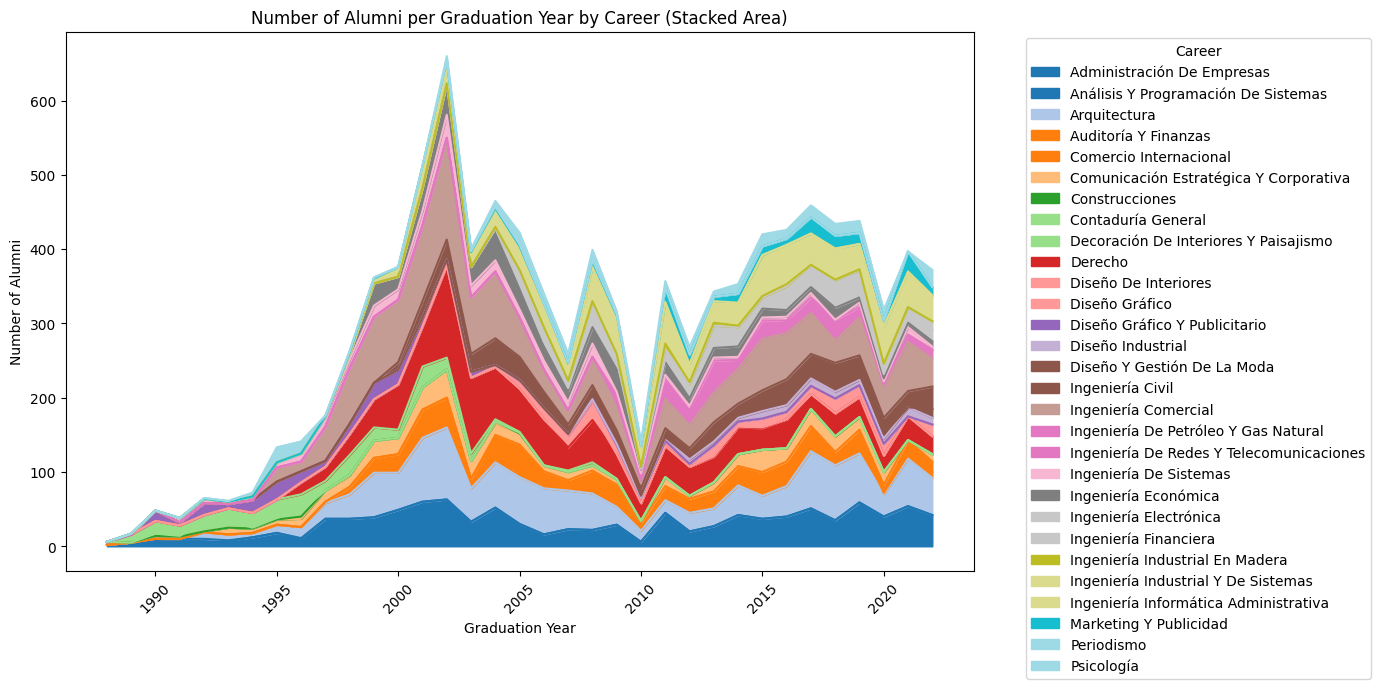

In [156]:

career_year_df = (
    alumni_df.groupby(['graduation_year', 'career'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

career_year_df.plot(
    kind='area',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title("Number of Alumni per Graduation Year by Career (Stacked Area)")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.xticks(rotation=45)
plt.legend(title="Career", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


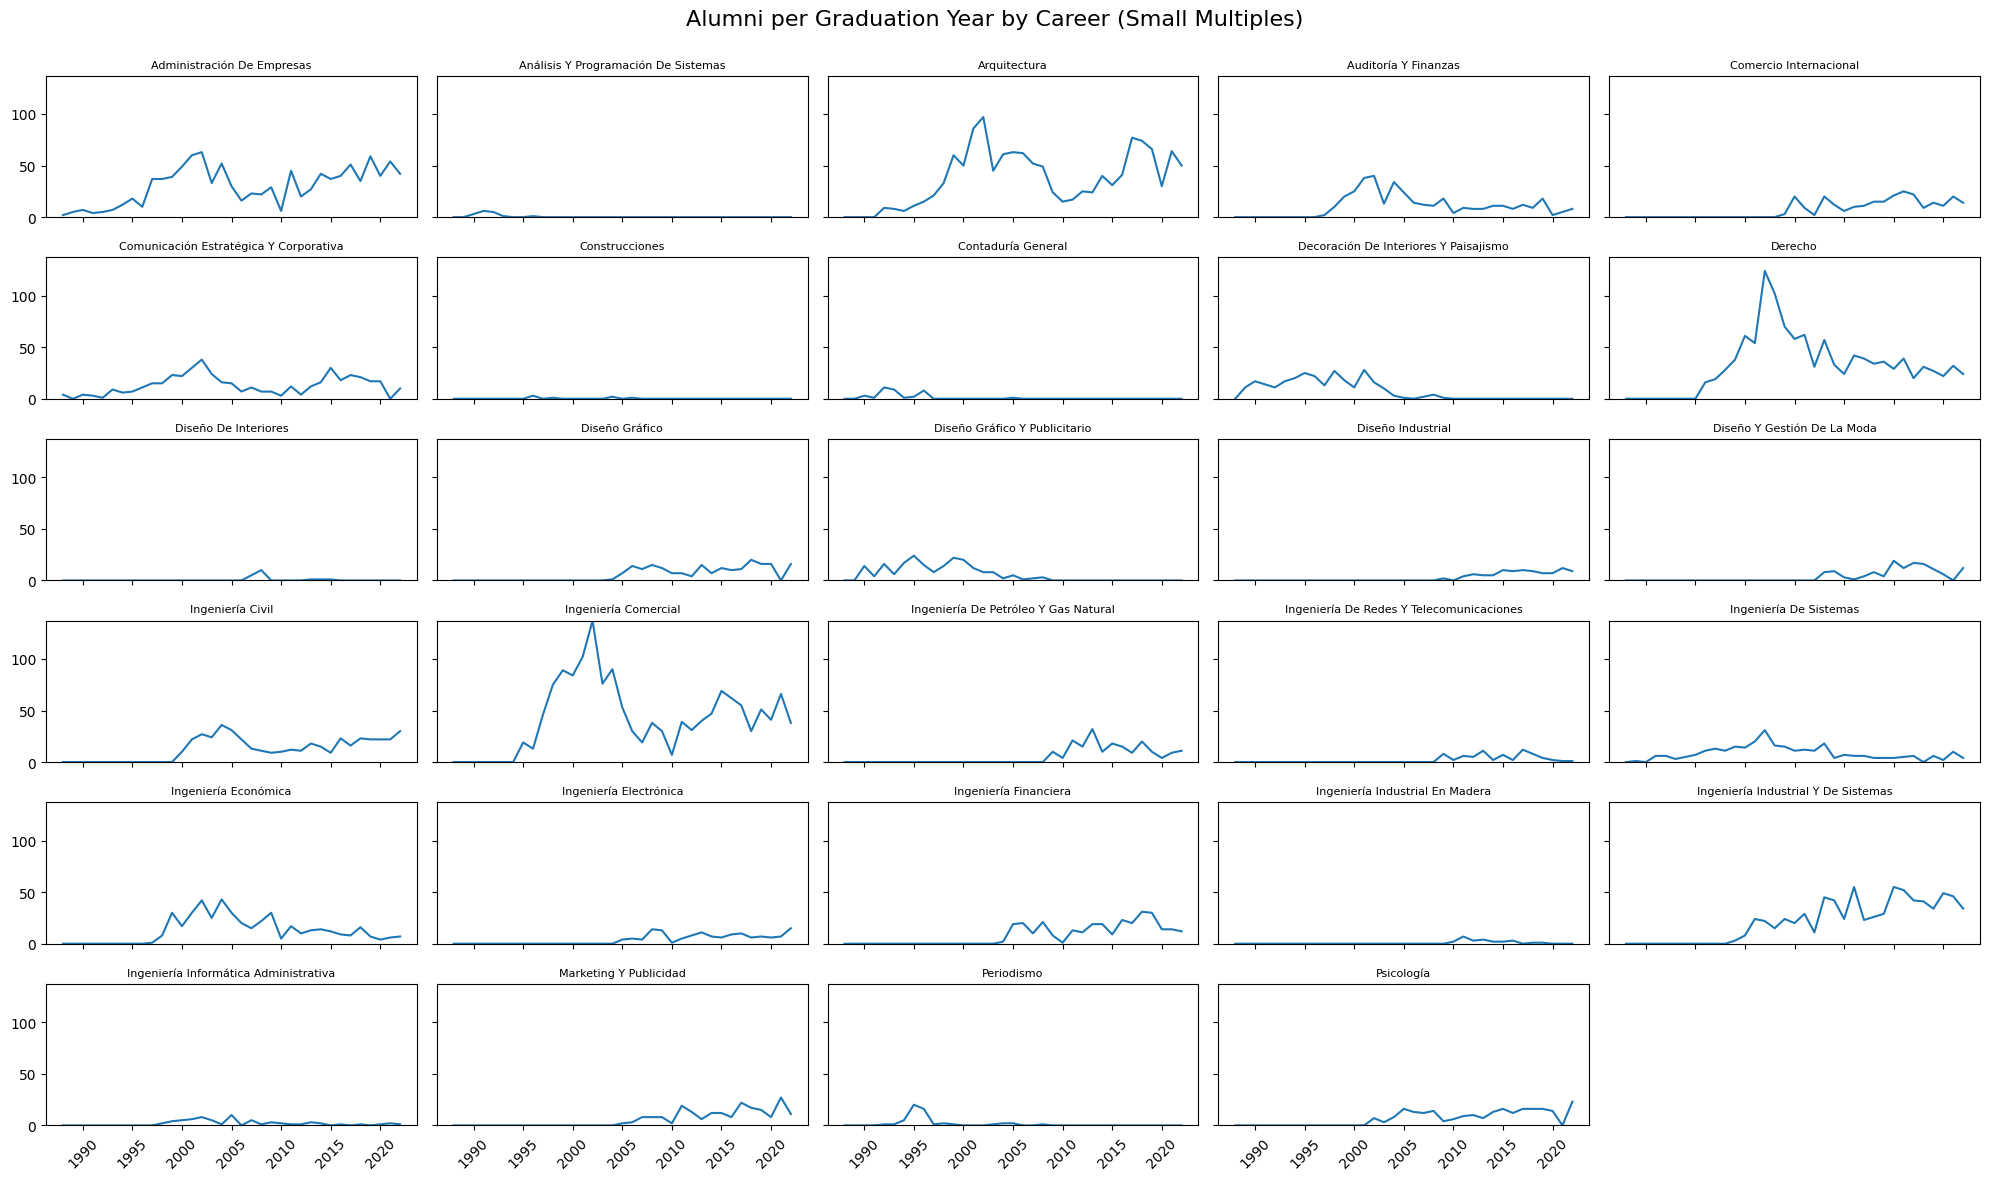

In [166]:
import math

n_careers = len(career_year_df.columns)
n_cols = 5
n_rows = math.ceil(n_careers / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 2), sharex=True, sharey=True)

for i, career in enumerate(career_year_df.columns):
    ax = axes.flat[i]
    ax.plot(career_year_df.index, career_year_df[career])
    ax.set_title(career, fontsize=8)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, career_year_df.values.max())

for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes.flat[j])

fig.suptitle("Alumni per Graduation Year by Career (Small Multiples)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Forecasting

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x, year_counts.values, 'o', label='Actual Data')
plt.plot(x_interp, spline(x_interp), '-', label='Spline Forecast', color='orange')
plt.title("Forecast of Alumni per Year")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Alumni")
plt.legend()
plt.tight_layout()
plt.show()